In [14]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#!pip3 install ultralytics
#!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


In [15]:
# Deep Learning
import torch
from torchvision import transforms
from ultralytics import YOLO
# Check for GPU availability
import tensorflow as tf
import os

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))



# Change the dataset path as needed (e.g., from Google Drive)
data_path = 'osteoporosis-knee-xray-dataset'  # Update to your dataset path


# Assuming 'data_path' is already defined as in your provided code
dataset_folders = os.listdir(data_path)

print(f"Number of folders in dataset: {len(dataset_folders)}")

for dataset_folder in dataset_folders:
    num_images = len(os.listdir(os.path.join(data_path, dataset_folder)))
    print(f"Number of images in '{dataset_folder}': {num_images}")


Num GPUs Available:  0
Number of folders in dataset: 2
Number of images in 'normal': 372
Number of images in 'osteoporosis': 372


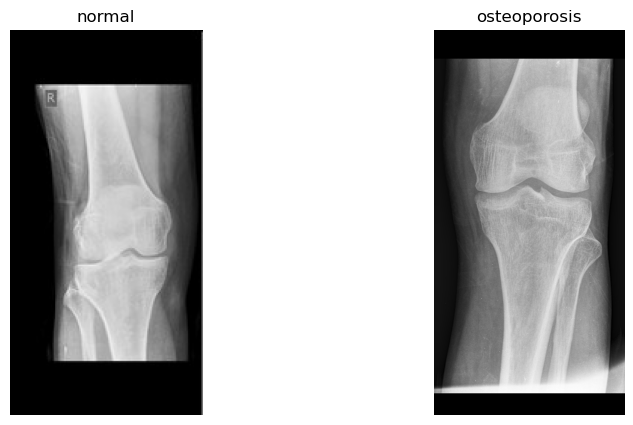

In [16]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# Assuming 'data_path' is already defined as in your provided code
dataset_folders = os.listdir(data_path)
data_dir_list = os.listdir(data_path)

plt.figure(figsize=(10, 5))  # Adjust figure size as needed
num_classes = len(dataset_folders)
for i, dataset_folder in enumerate(dataset_folders):
    image_files = os.listdir(os.path.join(data_path, dataset_folder))
    random_image_file = random.choice(image_files)  # Choose a random image
    image_path = os.path.join(data_path, dataset_folder, random_image_file)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_classes, i + 1)  # Create subplots for each class
    plt.imshow(image_rgb)
    plt.title(dataset_folder)
    plt.axis('off')

plt.show()

HOG feature vector shape: (1176,)
GLCM matrix shape: (256, 256, 1, 1)
ORB descriptors shape: (32, 32)


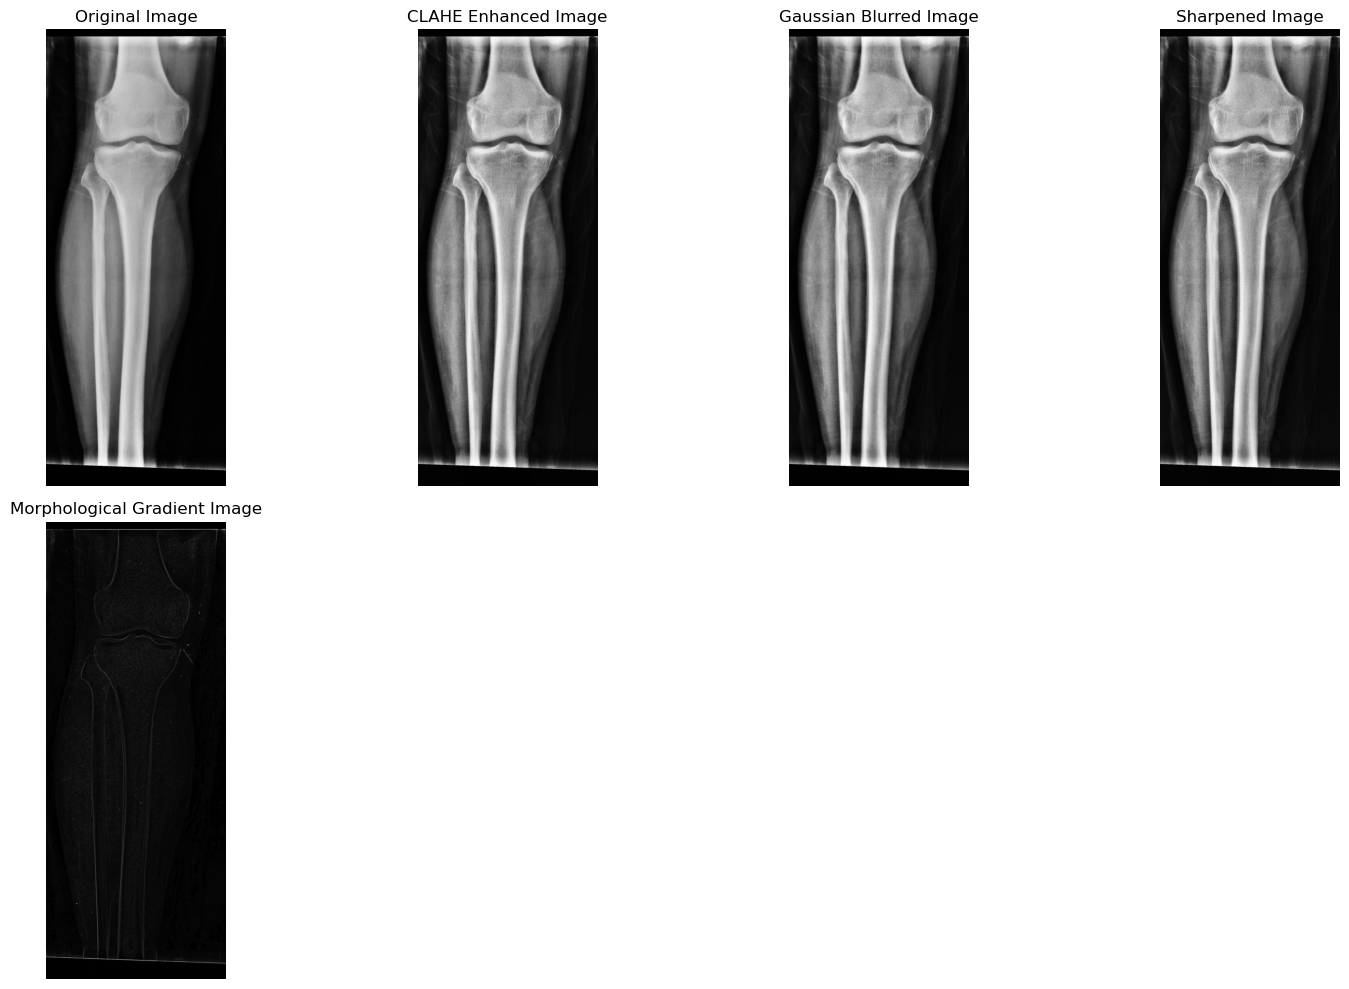

In [17]:
import cv2
import numpy as np
from skimage.feature import hog, graycomatrix, graycoprops
from skimage import exposure
import matplotlib.pyplot as plt

# Load the image
image_path = "osteoporosis-knee-xray-dataset/normal/2.jpg"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Preprocessing Steps
# 1. Apply CLAHE to improve local contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_image = clahe.apply(image)

# 2. Apply Gaussian Blurring to reduce noise
blurred_image = cv2.GaussianBlur(enhanced_image, (5, 5), 0)

# 3. Sharpen the image
sharpening_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened_image = cv2.filter2D(blurred_image, -1, sharpening_kernel)

# 4. Morphological Gradient to highlight boundaries
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morphed_image = cv2.morphologyEx(sharpened_image, cv2.MORPH_GRADIENT, kernel)

# Resize the final preprocessed image
resized_image = cv2.resize(morphed_image, (128, 128))

# Feature Extraction
# 5. Extract HOG features
hog_features, hog_image = hog(
    resized_image,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    orientations=6,
    visualize=True,
    feature_vector=True
)

# 6. Extract GLCM features
glcm = graycomatrix(resized_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]

# 7. Extract ORB keypoints and descriptors
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(resized_image, None)
orb_image = cv2.drawKeypoints(resized_image, keypoints, None, color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

# Print shapes of extracted features
print(f"HOG feature vector shape: {hog_features.shape}")
print(f"GLCM matrix shape: {glcm.shape}")
print(f"ORB descriptors shape: {descriptors.shape if descriptors is not None else 'No descriptors detected'}")


# Visualization
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# CLAHE Enhanced Image
plt.subplot(2, 4, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title('CLAHE Enhanced Image')
plt.axis('off')

# Blurred Image
plt.subplot(2, 4, 3)
plt.imshow(blurred_image, cmap='gray')
plt.title('Gaussian Blurred Image')
plt.axis('off')

# Sharpened Image
plt.subplot(2, 4, 4)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')
plt.axis('off')

# Morphological Gradient Image
plt.subplot(2, 4, 5)
plt.imshow(morphed_image, cmap='gray')
plt.title('Morphological Gradient Image')
plt.axis('off')

# Resized Image
""""plt.subplot(2, 4, 6)
plt.imshow(resized_image, cmap='gray')
plt.title('Resized Image (128x128)')
plt.axis('off')"""

plt.tight_layout()
plt.show()


In [18]:
# single image 
import importlib
import feature_extraction
importlib.reload(feature_extraction)
from feature_extraction import preprocess_knee, extract_hog_features, extract_glcm_features, extract_orb_features
img = preprocess_knee('osteoporosis-knee-xray-dataset/normal/2.jpg')
hog_features, _ = extract_hog_features(img)
glcm_features = extract_glcm_features(img)
orb_features = extract_orb_features(img)

print(f"HOG features shape: {hog_features.shape}")
print(f"GLCM features shape: {glcm_features.shape}")
print(f"ORB features shape: {orb_features.shape}")

HOG features shape: (1176,)
GLCM features shape: (20,)
ORB features shape: (500,)


In [19]:
# Feature Extraction Script ( for train stage)
import os
import numpy as np
from feature_extraction import (
    preprocess_knee,
    extract_hog_features,
    extract_glcm_features,
    extract_orb_features,
)

# Set your dataset directory
dataset_dir = "osteoporosis-knee-xray-dataset"  # Change as needed

# Optionally, load models once for efficiency
# Collect all image file paths
image_paths = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_paths.append(os.path.join(root, file))

print(f"Found {len(image_paths)} images.")

# Prepare lists to hold features and labels
features_list = [] # Combine features
hog_list = []
glcm_list = []
orb_list = []
labels_list = []

for img_path in image_paths:
    try:
        # Preprocess image
        img = preprocess_knee(img_path, image_size=(224, 224))
        # Extract features
        hog_features, _ = extract_hog_features(img)
        glcm_features = extract_glcm_features(img)
        orb_features = extract_orb_features(img)

        #features_list.append(all_features)
        hog_list.append(hog_features)
        glcm_list.append(glcm_features)     
        orb_list.append(orb_features)
        # Use parent directory as label
        label = os.path.basename(os.path.dirname(img_path))
        labels_list.append(label)
    except Exception as e:
        
        print(f"Error processing {img_path}: {e}")

# Convert to numpy arrays
#features_array = np.array(features_list)
labels_array = np.array(labels_list)
hog_array = np.array(hog_list)
glcm_array = np.array(glcm_list)
orb_array = np.array(orb_list)  
print("Feature extraction complete.")
# Print shapes of extracted features
print(f"HOG features shape: {hog_array.shape}")
print(f"GLCM features shape: {glcm_array.shape}")
print(f"ORB features shape: {orb_array.shape}")

print("-------------------- Finsh Feature Exctraction  --------------")


Found 744 images.
Feature extraction complete.
HOG features shape: (744, 1176)
GLCM features shape: (744, 20)
ORB features shape: (744, 500)
-------------------- Finsh Feature Exctraction  --------------


In [20]:
# Save features from each algorithm separately
os.makedirs('Bin_Features', exist_ok=True)
np.save('Bin_Features/hog_features_array.npy', hog_array)
np.save('Bin_Features/glcm_features_array.npy', glcm_array)
np.save('Bin_Features/orb_features_array.npy', orb_array)
np.save('Bin_Features/labels_array_all_algorithms.npy', labels_array)
print('Saved features for each algorithm and  features/labels as .npy files.')

Saved features for each algorithm and  features/labels as .npy files.


In [ ]:
# Feature Extraction Script (------ YOLO -----   for train stage)
import os
import numpy as np
import cv2
from PIL import Image
import torch

def preprocess_knee(image_path, image_size=(640, 640)):
    try:
        # Load image
        if image_path.lower().endswith('.dcm'):
            # Handle DICOM files if present
            try:
                import pydicom
                ds = pydicom.dcmread(image_path)
                image = ds.pixel_array
                # Convert to 8-bit if needed
                if image.dtype != np.uint8:
                    image = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
                # Convert grayscale to RGB
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            except ImportError:
                print("pydicom not available for DICOM files")
                return None
        else:
            # Handle standard image formats
            image = cv2.imread(image_path)
            if image is None:
                # Try with PIL as fallback
                pil_image = Image.open(image_path).convert('RGB')
                image = np.array(pil_image)
            else:
                # Convert BGR to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Resize image to YOLO input size
        image = cv2.resize(image, image_size)
        
        # Normalize to [0, 1] range (YOLO preprocessing)
        image = image.astype(np.float32) / 255.0
        
        return image
    
    except Exception as e:
        print(f"Error preprocessing image {image_path}: {e}")
        return None

def extract_yolo_features(image_array, yolo_model):
    """
    Extract features using YOLO model - method compatible with current YOLO architecture
    
    Args:
        image_array: Preprocessed image array
        yolo_model: Loaded YOLO model
    
    Returns:
        Feature vector as numpy array
    """
    try:
        if image_array is None or yolo_model is None:
            return None
        
        # Method 1: Use YOLO prediction results as features
        # Convert numpy array to PIL Image for YOLO prediction
        if len(image_array.shape) == 3:
            # Convert back to uint8 for YOLO prediction
            img_uint8 = (image_array * 255).astype(np.uint8)
            pil_image = Image.fromarray(img_uint8)
        else:
            return None
        
        # Get YOLO predictions
        results = yolo_model.predict(pil_image, verbose=False, device='cpu', conf=0.1)
        
        if results and len(results) > 0:
            result = results[0]
            
            # Extract multiple types of features
            features_list = []
            
            # 1. Detection-based features
            if result.boxes is not None and len(result.boxes) > 0:
                boxes = result.boxes
                
                # Bounding box features (normalized coordinates)
                if boxes.xywhn is not None:
                    coords = boxes.xywhn.cpu().numpy().flatten()
                    features_list.extend(coords)
                
                # Confidence scores
                if boxes.conf is not None:
                    confidences = boxes.conf.cpu().numpy()
                    features_list.extend(confidences)
                
                # Class predictions
                if boxes.cls is not None:
                    classes = boxes.cls.cpu().numpy()
                    features_list.extend(classes)
            
            # 2. Statistical features from the prediction process
            # Add image-level statistics as features
            img_stats = [
                np.mean(image_array),  # Mean intensity
                np.std(image_array),   # Standard deviation
                np.min(image_array),   # Min intensity
                np.max(image_array),   # Max intensity
                len(result.boxes) if result.boxes is not None else 0,  # Number of detections
            ]
            features_list.extend(img_stats)
            
            # 3. Create fixed-size feature vector
            feature_size = 128  # Fixed size for consistency
            features = np.zeros(feature_size)
            
            if len(features_list) > 0:
                # Fill with available features
                features[:min(len(features_list), feature_size)] = features_list[:min(len(features_list), feature_size)]
            
            # 4. Add spatial features (simple grid-based analysis)
            h, w = image_array.shape[:2]
            grid_size = 4
            grid_h, grid_w = h // grid_size, w // grid_size
            
            grid_features = []
            for i in range(grid_size):
                for j in range(grid_size):
                    y1, y2 = i * grid_h, min((i + 1) * grid_h, h)
                    x1, x2 = j * grid_w, min((j + 1) * grid_w, w)
                    grid_region = image_array[y1:y2, x1:x2]
                    grid_features.append(np.mean(grid_region))
            
            # Add grid features to remaining space
            remaining_space = feature_size - len(features_list)
            if remaining_space > 0 and len(grid_features) > 0:
                grid_features = grid_features[:remaining_space]
                features[len(features_list):len(features_list)+len(grid_features)] = grid_features
            
            return features
        
        else:
            # No detections - create features from image statistics only
            feature_size = 128
            features = np.zeros(feature_size)
            
            # Basic image statistics
            img_stats = [
                np.mean(image_array),
                np.std(image_array),
                np.min(image_array),
                np.max(image_array),
                np.median(image_array),
            ]
            
            # Add spatial features (grid-based analysis)
            h, w = image_array.shape[:2]
            grid_size = 8
            grid_h, grid_w = h // grid_size, w // grid_size
            
            grid_features = []
            for i in range(grid_size):
                for j in range(grid_size):
                    y1, y2 = i * grid_h, min((i + 1) * grid_h, h)
                    x1, x2 = j * grid_w, min((j + 1) * grid_w, w)
                    grid_region = image_array[y1:y2, x1:x2]
                    grid_features.extend([np.mean(grid_region), np.std(grid_region)])
            
            # Combine all features
            all_features = img_stats + grid_features
            features[:min(len(all_features), feature_size)] = all_features[:min(len(all_features), feature_size)]
            
            return features
    
    except Exception as e:
        print(f"Error extracting YOLO features: {e}")
        # Last resort: return image-based statistical features
        try:
            if image_array is not None:
                feature_size = 128
                features = np.zeros(feature_size)
                
                # Basic statistics
                basic_stats = [
                    np.mean(image_array),
                    np.std(image_array),
                    np.var(image_array),
                    np.min(image_array),
                    np.max(image_array),
                    np.median(image_array),
                    np.percentile(image_array, 25),
                    np.percentile(image_array, 75),
                ]
                
                # Fill features array
                features[:min(len(basic_stats), feature_size)] = basic_stats[:min(len(basic_stats), feature_size)]
                return features
            else:
                return np.zeros(128)
        except:
            return np.zeros(128)  # Return zero vector as absolute last resort

# Set your dataset directory
dataset_dir = "osteoporosis-knee-xray-dataset"  # Change as needed

# Force CPU usage for PyTorch
torch.set_num_threads(4)  # Optimize for your CPU cores
device = 'cpu'
print(f"Using device: {device}")

# Load YOLO model once for efficiency (CPU optimized)
yolo_model = None
try:
    print("Loading YOLO model for CPU...")
    from ultralytics import YOLO
    
    # Use smaller YOLO model for CPU efficiency
    yolo_model = YOLO('yolov8n.pt')  # nano version for better CPU performance
    
    # Explicitly set to CPU
    yolo_model.to('cpu')
    
    # Optimize model for inference
    yolo_model.model.eval()
    
    print("YOLO model loaded successfully on CPU!")
    
except ImportError:
    print("Ultralytics not available. Please install: pip install ultralytics")
    exit(1)
except Exception as e:
    print(f"Error loading YOLO model: {e}")
    print("Trying to download the model...")
    try:
        yolo_model = YOLO('yolov11m.pt')  # This will download if not present
        yolo_model.to('cpu')
        print("YOLO model downloaded and loaded successfully!")
    except Exception as download_e:
        print(f"Failed to download/load YOLO model: {download_e}")
        exit(1)

# Collect all image file paths
print("Collecting image paths...")
image_paths = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.dcm')):
            image_paths.append(os.path.join(root, file))

print(f"Found {len(image_paths)} images.")

if len(image_paths) == 0:
    print(f"No images found in directory: {dataset_dir}")
    print("Please check the dataset directory path and ensure it contains images.")
    exit(1)

# Prepare lists to hold features and labels
yolo_list = []
labels_list = []
processed_count = 0
failed_count = 0

print("Starting YOLO feature extraction...")
print("Note: Processing on CPU may be slower. Please be patient...")

for i, img_path in enumerate(image_paths):
    try:
        # Preprocess image (using 640x640 for YOLO, but you can change to 224x224 if needed)
        img = preprocess_knee(img_path, image_size=(640, 640))
        
        if img is not None:
            # Extract YOLO features
            yolo_features = extract_yolo_features(img, yolo_model)
            
            if yolo_features is not None and len(yolo_features) > 0:
                yolo_list.append(yolo_features)
                # Use parent directory as label
                label = os.path.basename(os.path.dirname(img_path))
                labels_list.append(label)
                processed_count += 1
                
                # Show progress every 10 images (more frequent due to slower CPU processing)
                if (i + 1) % 10 == 0 or (i + 1) == len(image_paths):
                    print(f"Processed {i + 1}/{len(image_paths)} images... "
                          f"(Success: {processed_count}, Failed: {failed_count})")
            else:
                failed_count += 1
                print(f"Failed to extract features from: {os.path.basename(img_path)}")
        else:
            failed_count += 1
            print(f"Failed to preprocess: {os.path.basename(img_path)}")
            
    except Exception as e:
        failed_count += 1
        print(f"Error processing {img_path}: {e}")

# Convert to numpy arrays
yolo_array = np.array(yolo_list) if yolo_list else None
labels_array = np.array(labels_list) if labels_list else None

print("Feature extraction complete.")
print(f"Successfully processed: {processed_count} images")
print(f"Failed to process: {failed_count} images")

# Print shapes of extracted features
if yolo_array is not None:
    print(f"YOLO features shape: {yolo_array.shape}")
    print(f"Feature vector length: {yolo_array.shape[1]}")
else:
    print("No features were extracted!")

if labels_array is not None:
    print(f"Labels shape: {labels_array.shape}")
    unique_labels = np.unique(labels_array)
    print(f"Number of unique labels: {len(unique_labels)}")
    print(f"Labels: {unique_labels}")
    
    # Print label distribution
    print("\nLabel distribution:")
    for label in unique_labels:
        count = np.sum(labels_array == label)
        print(f"  {label}: {count} images")
else:
    print("No labels were extracted!")

# Optional: Save features and labels
'''if yolo_array is not None and labels_array is not None:
    try:
        np.save('yolo_features.npy', yolo_array)
        np.save('labels.npy', labels_array)
        print("\nFeatures and labels saved to:")
        print("  - yolo_features.npy")
        print("  - labels.npy")
    except Exception as e:
        print(f"Error saving files: {e}")'''

# Memory cleanup
if yolo_model is not None:
    del yolo_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("-------------------- Finish Feature Extraction --------------")

Using device: cpu
Loading YOLO model for CPU...
YOLO model loaded successfully on CPU!
Found 744 images.
Starting YOLO feature extraction...
Note: Processing on CPU may be slower. Please be patient...
Processed 10/744 images... (Success: 10, Failed: 0)
Processed 20/744 images... (Success: 20, Failed: 0)
Processed 30/744 images... (Success: 30, Failed: 0)
Processed 40/744 images... (Success: 40, Failed: 0)
Processed 50/744 images... (Success: 50, Failed: 0)
Processed 60/744 images... (Success: 60, Failed: 0)
Processed 70/744 images... (Success: 70, Failed: 0)
Processed 80/744 images... (Success: 80, Failed: 0)
Processed 90/744 images... (Success: 90, Failed: 0)
Processed 100/744 images... (Success: 100, Failed: 0)
Processed 110/744 images... (Success: 110, Failed: 0)
Processed 120/744 images... (Success: 120, Failed: 0)
Processed 130/744 images... (Success: 130, Failed: 0)
Processed 140/744 images... (Success: 140, Failed: 0)
Processed 150/744 images... (Success: 150, Failed: 0)
Process

In [23]:
np.save('Bin_Features/yolo_features_array.npy', yolo_array)

In [24]:
# Feature Extraction Script ( ---- VGG -------for train stage)
import os
import numpy as np
from feature_extraction import (
    preprocess_knee,
    extract_vgg_features,
)

# Set your dataset directory
dataset_dir = "osteoporosis-knee-xray-dataset"  # Change as needed

# Optionally, load models once for efficiency
vgg_model = None
try:
    from tensorflow.keras.applications import VGG16
    vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
except ImportError:
    pass


# Collect all image file paths
image_paths = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_paths.append(os.path.join(root, file))

print(f"Found {len(image_paths)} images.")

# Prepare lists to hold features and labels
vgg_list = []
labels_list = []

for img_path in image_paths:
    try:
        # Preprocess image
        img = preprocess_knee(img_path, image_size=(224, 224))
        # Extract features
        vgg_features = extract_vgg_features(img, vgg_model)
        vgg_list.append(vgg_features)
        # Use parent directory as label
        label = os.path.basename(os.path.dirname(img_path))
        labels_list.append(label)
    except Exception as e:
        
        print(f"Error processing {img_path}: {e}")

# Convert to numpy arrays
vgg_array = np.array(vgg_list) if vgg_list else None
print("Feature extraction complete.")
# Print shapes of extracted features

if vgg_array is not None:
    print(f"VGG features shape: {vgg_array.shape}")
print("-------------------- Finsh Feature Exctraction  --------------")


Found 744 images.
Feature extraction complete.
VGG features shape: (744, 512)
-------------------- Finsh Feature Exctraction  --------------


In [26]:
np.save('Bin_Features/vgg_features_array.npy', vgg_array)

In [27]:
# Feature Extraction Script ( for train stage)
import os
import numpy as np
from feature_extraction import (
    preprocess_knee,
    extract_resnet50_features  # <-- Add this import
)

# Set your dataset directory
dataset_dir = "osteoporosis-knee-xray-dataset"  # Change as needed

# Optionally, load models once for efficiency

resnet_model = None
try:
    from tensorflow.keras.applications import VGG16, ResNet50
    resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
except ImportError:
    pass


# Collect all image file paths
image_paths = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_paths.append(os.path.join(root, file))

print(f"Found {len(image_paths)} images.")

# Prepare lists to hold features and labels
resnet_list = []


#hog_features --- IGNORE ---
#hog_features --- IGNORE ---
labels_list = []

for img_path in image_paths:
    try:
        # Preprocess image
        img = preprocess_knee(img_path, image_size=(224, 224))
        # Extract features
       
        resnet_features = extract_resnet50_features(img, resnet_model)
       
        resnet_list.append(resnet_features)


        # Use parent directory as label
        label = os.path.basename(os.path.dirname(img_path))
        labels_list.append(label)
    except Exception as e:
        
        print(f"Error processing {img_path}: {e}")

# Convert to numpy arrays

resnet_array = np.array(resnet_list) if resnet_list else None
print("Feature extraction complete.")
# Print shapes of extracted features

if resnet_array is not None:
    print(f"ResNet features shape: {resnet_array.shape}")
print("-------------------- Finsh Feature Exctraction  --------------")


Found 744 images.
Feature extraction complete.
ResNet features shape: (744, 2048)
-------------------- Finsh Feature Exctraction  --------------


In [25]:
np.save('Bin_Features/resnet_features_array.npy', resnet_array)

In [11]:
# Load saved feature arrays (ML) and combine them
import numpy as np

hog_array = np.load('Bin_Features/hog_features_array.npy')
glcm_array = np.load('Bin_Features/glcm_features_array.npy')
orb_array = np.load('Bin_Features/orb_features_array.npy')
labels_array = np.load('Bin_Features/labels_array_all_algorithms.npy')

# Combine features along the last axis (if shapes are compatible)
combined_ML_features = np.concatenate([hog_array, glcm_array, orb_array], axis=1)

print('Combined ML features shape:', combined_ML_features.shape)
print('Labels shape:', labels_array.shape)

# Optionally, save the combined features
np.save('Bin_Features/combined_ML_features_array.npy', combined_ML_features)
print('Combined features saved to Bin_Features/combined_ML_features_array.npy')

Combined ML features shape: (744, 1696)
Labels shape: (744,)
Combined features saved to Bin_Features/combined_ML_features_array.npy


In [12]:
# Load feature arrays (VGG, YOLO, ResNet) and combine them
import numpy as np

vgg_array = np.load('Bin_Features/vgg_features_array.npy')
yolo_array = np.load('Bin_Features/yolo_features_array.npy')
resnet_array = np.load('Bin_Features/resnet_features_array.npy')
labels_array = np.load('Bin_Features/labels_array_all_algorithms.npy')

# Combine features along the last axis (if shapes are compatible)
combined_DL_features = np.concatenate([vgg_array, yolo_array, resnet_array], axis=1)

print('Combined Deep Learning features shape:', combined_DL_features.shape)
print('Labels shape:', labels_array.shape)

# Optionally, save the combined features
np.save('Bin_Features/combined_DL_features_array.npy', combined_DL_features)
print('Combined features saved to Bin_Features/combined_DL_features_array.npy')

Combined Deep Learning features shape: (744, 2688)
Labels shape: (744,)
Combined features saved to Bin_Features/combined_DL_features_array.npy


In [13]:
# Combine ML and DL features into a single array
import numpy as np
ml_features = np.load('Bin_Features/combined_ML_features_array.npy')
dl_features = np.load('Bin_Features/combined_DL_features_array.npy')
labels_array = np.load('Bin_Features/labels_array_all_algorithms.npy')
combined_all_features = np.concatenate([ml_features, dl_features], axis=1)
print('Combined ALL features shape:', combined_all_features.shape)
print('Labels shape:', labels_array.shape)
# Optionally, save the combined features
np.save('Bin_Features/combined_all_features_array.npy', combined_all_features)
print('Combined ALL features saved to Bin_Features/combined_all_features_array.npy')

Combined ALL features shape: (744, 4384)
Labels shape: (744,)
Combined ALL features saved to Bin_Features/combined_all_features_array.npy
